# Simple Tide Current Script

Written by Jean Rabault ([@jerabaul29](https://github.com/jerabaul29)) 

the aim of this notebook is to illustrate the use of the Arc2kmTM tidal model, used py pyTMD
and to provide a short, minimalistic example of how to use pyTMD to predict tidal currents
note that if you want to use another of the models supported by pyTMD, you may need to do small changes to the code

.. tip::
    see the `Arc2kmTM_README_v1.pdf` document, `Arc2kmTM`: Model Summary, for units

In [1]:
import datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# import tide programs
import pyTMD
import timescale

In [2]:
# validate against the data from:
# https://www.nature.com/articles/s41597-020-00578-z/tables/2
# available at:
# https://arcticdata.io/catalog/view/doi:10.18739/A26M3340D
# we use the dataset for validation (from List_of_records.txt):
# bar_BSO3_a_rcm7_2008_09.nc

In [3]:
obs = xr.open_dataset("bar_BSO3_a_rcm7_2008_09.nc", drop_variables=["six_con", "all_con"])
obs

<xarray.Dataset> Size: 1MB
Dimensions:          (time_5d: 73, press: 1, time: 26381, six_con: 6,
                      all_con: 67)
Coordinates:
  * time             (time) datetime64[ns] 211kB 2008-06-27T23:00:00.000003 ....
Dimensions without coordinates: time_5d, press, six_con, all_con
Data variables: (12/33)
    time_5day        (time_5d) datetime64[ns] 584B ...
    pressure         (press) float64 8B ...
    pressure_flag    (press) float64 8B ...
    latitude         float64 8B ...
    longitude        float64 8B ...
    u_TBC            (time, press) float64 211kB ...
    ...               ...
    min_amp_FR       (all_con, press) float64 536B ...
    min_amp_err_FR   (all_con, press) float64 536B ...
    ori_FR           (all_con, press) float64 536B ...
    ori_err_FR       (all_con, press) float64 536B ...
    phase_FR         (all_con, press) float64 536B ...
    phase_err_FR     (all_con, press) float64 536B ...
Attributes:
    mooring_name:                 BSO3_a
    region:                       Barents Sea
    source_data_institution:      Institute of Marine Research (IMR, Norway)
    source_data_doi:              N/A
    source_data_link_or_contact:  Randi Ingvaldsen (randi.ingvaldsen@hi.no)
    source_data_citation:         N/A
    instrument:                   Recording Current Meter (point measure), Aa...
    start_time:                   26-Jun-2008
    end_time:                     28-Jun-2009
    time_increment_in_minutes:    20
    depth_range_in_meters:        50
    depth_increment_in_meters:    NaN

In [4]:
# where on the Earth we are getting data
print(f"{obs.latitude.data = }")
print(f"{obs.longitude.data = }")

# when we are getting data
print(f"{obs.time[0].data = }")
print(f"{obs.time[-1].data = }")

obs.latitude.data = array(72.502)
obs.longitude.data = array(19.56083333)
obs.time[0].data = array('2008-06-27T23:00:00.000003000', dtype='datetime64[ns]')
obs.time[-1].data = array('2009-06-29T08:20:00.000002000', dtype='datetime64[ns]')


In [5]:
# read tide model
model = pyTMD.io.model().from_database("Arc2kmTM")
# read tidal currents (note lowercase!)
dtree = model.open_datatree(group=("u", "v"))
# create timescale object from dataset time stamps
ts = timescale.from_datetime(obs.time)

In [6]:
# actually perform the prediction
X, Y = dtree.tmd.coords_as(obs.longitude, obs.latitude, crs=4326)
# as long as the location is not changed, this can be used many times to predict for different times
local = dtree.tmd.interp(X, Y, extrapolate=True)

# this is to predict a time series at a single location over many times
tpred = {}
for key, ds in local.items():
    # convert to dataset
    ds = ds.to_dataset()
    tpred[key] = ds.tmd.predict(ts.tide, corrections=model.corrections) 
    tpred[key] += ds.tmd.infer(ts.tide, corrections=model.corrections)

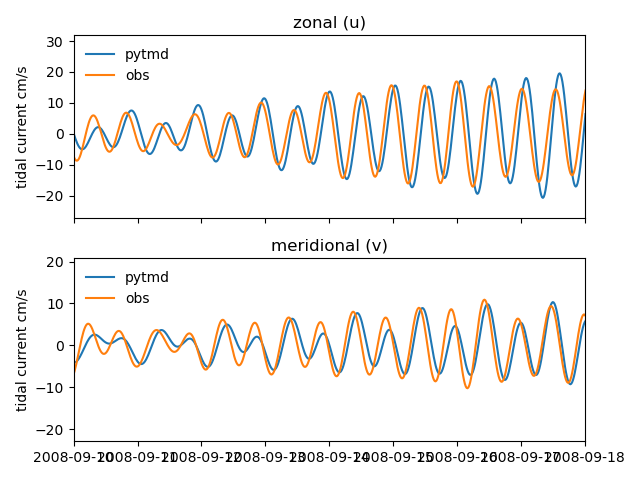

In [7]:
%matplotlib widget
# compare the model data generated by pyTMD to observed tidal currents computed over a long time series
fig, ax= plt.subplots(nrows=2, sharex=True)
ax[0].plot(obs.time, tpred["u"], label="pytmd")
ax[0].plot(obs.time, obs["u_TBC"], label="obs")
ax[0].set_xlim(datetime.date(2008, 9, 10), datetime.date(2008, 9, 18))
ax[0].legend(frameon=False)
ax[0].set_ylabel("tidal current cm/s")
ax[0].set_title("zonal (u)")
plt.plot(obs.time, tpred["v"], label="pytmd")
plt.plot(obs.time, obs["v_TBC"], label="obs")
ax[1].set_ylabel("tidal current cm/s")
ax[1].set_title("meridional (v)")
ax[1].legend(frameon=False)
fig.tight_layout()

### a bit underestimated, but not so bad for a global model!